# COVID vs CONTROL Classification — Frozen ADNI Encoder Probing

**Pipeline:** Supervised probing with frozen β-VAE encoders (trained on ADNI AD vs CN) applied to COVID cohort fMRI  
**Experiment:** `covid_classification_probing` — binary COVID vs CONTROL classification  
**Date:** March 2026  

---

### How this differs from the previous AD-likeness transfer analysis

The earlier notebook (`03_b_transfer_v1_audit`) evaluated whether the **AD-likeness score** — a single scalar probability of Alzheimer's disease extracted from each ADNI-trained fold — was informative about COVID status. That analysis operated on the *classifier's output* (a pre-trained AD vs CN probability) and tested it directly as a transfer biomarker.

This notebook takes a fundamentally different approach: we use only the **frozen encoder** from each ADNI-trained β-VAE to extract 256-dimensional latent representations (μ vectors), then train **new supervised classifiers** on those representations to discriminate COVID vs CONTROL. The downstream classifiers (logistic regression and SVM) are trained and evaluated entirely within the COVID cohort using stratified cross-validation.

### Why latent vectors from independent VAE folds cannot be averaged

Each of the five ADNI encoder folds learns a different latent space. Because VAEs are trained with stochastic optimization and the latent dimensions are not identifiable across training runs (there is no canonical alignment of the latent axes), averaging μ vectors across encoders would be meaningless — dimension `latent_42` in fold 1 has no guaranteed correspondence to `latent_42` in fold 2.

### Why late fusion of predicted scores is valid

Although raw latent vectors live in incompatible spaces, the **predicted scores** from classifiers trained on each encoder's latents share a common semantics: they rank subjects by COVID-likeness. For **logistic regression**, the score is `predict_proba[:,1]` (a probability in [0, 1]); for **SVM** (`probability=False`), the score is `decision_function` (an unbounded signed margin). Even though these score types have different scales, averaging across encoders *within* each classifier type is valid because the scores are commensurable and AUC is rank-based. Majority-vote is used for the fused hard prediction.

### Feature families

| Family | Features | Dim | Encoder-dependent? |
|---|---|---|---|
| `metadata_only` | Age, Sex | 2 | **No** — trained once as a true baseline |
| `latent_only` | μ₀ … μ₂₅₅ (frozen encoder) | 256 | Yes — one model per encoder fold |
| `latent_plus_metadata` | μ₀ … μ₂₅₅ + Age + Sex | 258 | Yes |

> **Note:** `metadata_only` does not use any encoder output, so it is trained once per (CV fold × classifier) combination and enters late fusion with `n_encoders_fused = 1` (no actual averaging).

## §1 — Setup & Path Validation

In [13]:
import warnings, logging
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, message=".*tight_layout.*")
logging.getLogger("matplotlib").setLevel(logging.WARNING)

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

%matplotlib inline

# ── Project imports ──────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().resolve().parent
SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.is_dir() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from betavae_xai.analysis_qc import (
    set_publication_style, create_color_palette, save_figure,
)

set_publication_style("paper")
FIG_FORMATS = ["png", "pdf"]

# ── Toggle ────────────────────────────────────────────────────────
SHOW_FIGURES: bool = True

def show_fig(fig):
    if SHOW_FIGURES and fig is not None:
        fig.canvas.draw()
        display(fig)

print("[OK] Imports ready.")

[OK] Imports ready.


In [14]:
# ── Paths ────────────────────────────────────────────────────────
RESULTS_DIR = PROJECT_ROOT / "results" / "vae_3channels_beta65_pro" / "covid_classification_probing"
TABLES_DIR = RESULTS_DIR / "Tables"
FIG_DIR = RESULTS_DIR / "Figures" / "audit"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Load tables ──────────────────────────────────────────────────
metrics_fold = pd.read_csv(TABLES_DIR / "metrics_by_fold_encoder_model.csv")
oof_encoder  = pd.read_csv(TABLES_DIR / "oof_predictions_by_encoder_model.csv")
oof_fusion   = pd.read_csv(TABLES_DIR / "oof_predictions_late_fusion.csv")
summary_enc  = pd.read_csv(TABLES_DIR / "summary_by_encoder_model.csv")
summary_fus  = pd.read_csv(TABLES_DIR / "summary_late_fusion.csv")
feat_schema  = pd.read_csv(TABLES_DIR / "feature_schema_summary.csv")

tables = {
    "metrics_by_fold_encoder_model": metrics_fold,
    "oof_predictions_by_encoder_model": oof_encoder,
    "oof_predictions_late_fusion": oof_fusion,
    "summary_by_encoder_model": summary_enc,
    "summary_late_fusion": summary_fus,
    "feature_schema_summary": feat_schema,
}

for name, df in tables.items():
    print(f"{name:42s}  shape={str(df.shape):12s}  cols={list(df.columns)}")

print(f"\nFigures will be saved to: {FIG_DIR}")

metrics_by_fold_encoder_model               shape=(110, 13)     cols=['covid_outer_fold', 'adni_encoder_fold', 'model_type', 'feature_family', 'n_train', 'n_test', 'auc', 'pr_auc', 'balanced_accuracy', 'accuracy', 'f1', 'sensitivity', 'specificity']
oof_predictions_by_encoder_model            shape=(4268, 8)     cols=['SubjectID', 'y_true', 'covid_outer_fold', 'adni_encoder_fold', 'model_type', 'feature_family', 'y_score', 'y_pred']
oof_predictions_late_fusion                 shape=(1164, 8)     cols=['SubjectID', 'y_true', 'covid_outer_fold', 'model_type', 'feature_family', 'y_score_fused', 'y_pred_fused', 'n_encoders_fused']
summary_by_encoder_model                    shape=(22, 11)      cols=['adni_encoder_fold', 'model_type', 'feature_family', 'auc_mean', 'auc_std', 'pr_auc_mean', 'balanced_accuracy_mean', 'f1_mean', 'sensitivity_mean', 'specificity_mean', 'n_folds']
summary_late_fusion                         shape=(6, 17)       cols=['model_type', 'feature_family', 'auc_mean', 'a

## §2 — Cohort Audit

In [15]:
# ── Basic cohort numbers from late-fusion OOF table ──────────────
# Pick one model×family combination — each contains all subjects once
_one = oof_fusion.query("model_type == 'logreg' and feature_family == 'metadata_only'")
n_total = _one.shape[0]
n_covid = (_one.y_true == 1).sum()
n_ctrl  = (_one.y_true == 0).sum()

# Design parameters
encoder_folds = sorted(metrics_fold.adni_encoder_fold.unique())
covid_folds   = sorted(metrics_fold.covid_outer_fold.unique())
classifiers   = sorted(metrics_fold.model_type.unique())
families      = metrics_fold.feature_family.unique().tolist()

# metadata_only has adni_encoder_fold=0 (trained once, encoder-independent)
latent_enc_folds = sorted(
    metrics_fold[metrics_fold.feature_family != "metadata_only"].adni_encoder_fold.unique()
)
n_latent_families = len([f for f in families if f != "metadata_only"])

print("Cohort")
print(f"  Total subjects:        {n_total}")
print(f"  COVID:                 {n_covid}")
print(f"  CONTROL:               {n_ctrl}")
print(f"  Prevalence (COVID %):  {100*n_covid/n_total:.1f}%")
print()
print("Experimental design")
print(f"  ADNI encoder folds (latent families):  {latent_enc_folds}")
print(f"  metadata_only encoder fold (sentinel):  [0]  (trained once)")
print(f"  COVID outer CV folds:  {covid_folds}")
print(f"  Classifiers:           {classifiers}")
print(f"  Feature families:      {families}")
n_latent_fits = n_latent_families * len(latent_enc_folds) * len(covid_folds) * len(classifiers)
n_meta_fits   = 1 * len(covid_folds) * len(classifiers)
print(f"  Total fits:            {metrics_fold.shape[0]}  "
      f"(latent: {n_latent_families}×{len(latent_enc_folds)}×{len(covid_folds)}"
      f"×{len(classifiers)} = {n_latent_fits}  +  "
      f"metadata_only: 1×{len(covid_folds)}×{len(classifiers)} = {n_meta_fits})")
print()
display(feat_schema)

Cohort
  Total subjects:        194
  COVID:                 151
  CONTROL:               43
  Prevalence (COVID %):  77.8%

Experimental design
  ADNI encoder folds (latent families):  [1, 2, 3, 4, 5]
  metadata_only encoder fold (sentinel):  [0]  (trained once)
  COVID outer CV folds:  [0, 1, 2, 3, 4]
  Classifiers:           ['logreg', 'svm']
  Feature families:      ['latent_only', 'metadata_only', 'latent_plus_metadata']
  Total fits:            110  (latent: 2×5×5×2 = 100  +  metadata_only: 1×5×2 = 10)



,feature_family,latent_dim,metadata_columns,final_feature_count,latent_type,selected_channels
0,latent_only,256,NaN,256,mu,"Pearson_Full_FisherZ_Signed, Pearson_OMST_GCE_..."
1,metadata_only,0,"Age, Sex",2,NaN,NaN
2,latent_plus_metadata,256,"Age, Sex",258,mu,"Pearson_Full_FisherZ_Signed, Pearson_OMST_GCE_..."


## §3 — Per-Encoder Performance

In [16]:
# ── Global palette for feature families ──────────────────────────
FAMILY_ORDER = ["metadata_only", "latent_only", "latent_plus_metadata"]
FAMILY_LABELS = {
    "metadata_only": "Age + Sex",
    "latent_only": "Latent (256-d)",
    "latent_plus_metadata": "Latent + Age + Sex",
}
FAMILY_PALETTE = {
    "metadata_only":         "#2ca02c",  # green
    "latent_only":           "#1f77b4",  # blue
    "latent_plus_metadata":  "#d62728",  # red
}
CLF_LABELS = {"logreg": "Logistic Regression", "svm": "SVM"}

# Map readable labels
metrics_fold["family_label"] = metrics_fold.feature_family.map(FAMILY_LABELS)
metrics_fold["clf_label"]    = metrics_fold.model_type.map(CLF_LABELS)

LABEL_PALETTE = {FAMILY_LABELS[k]: v for k, v in FAMILY_PALETTE.items()}

print("[OK] Palette defined.")

[OK] Palette defined.


Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/covid_classification_probing/Figures/audit/fig_auc_by_encoder_fold.png
Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/covid_classification_probing/Figures/audit/fig_auc_by_encoder_fold.pdf


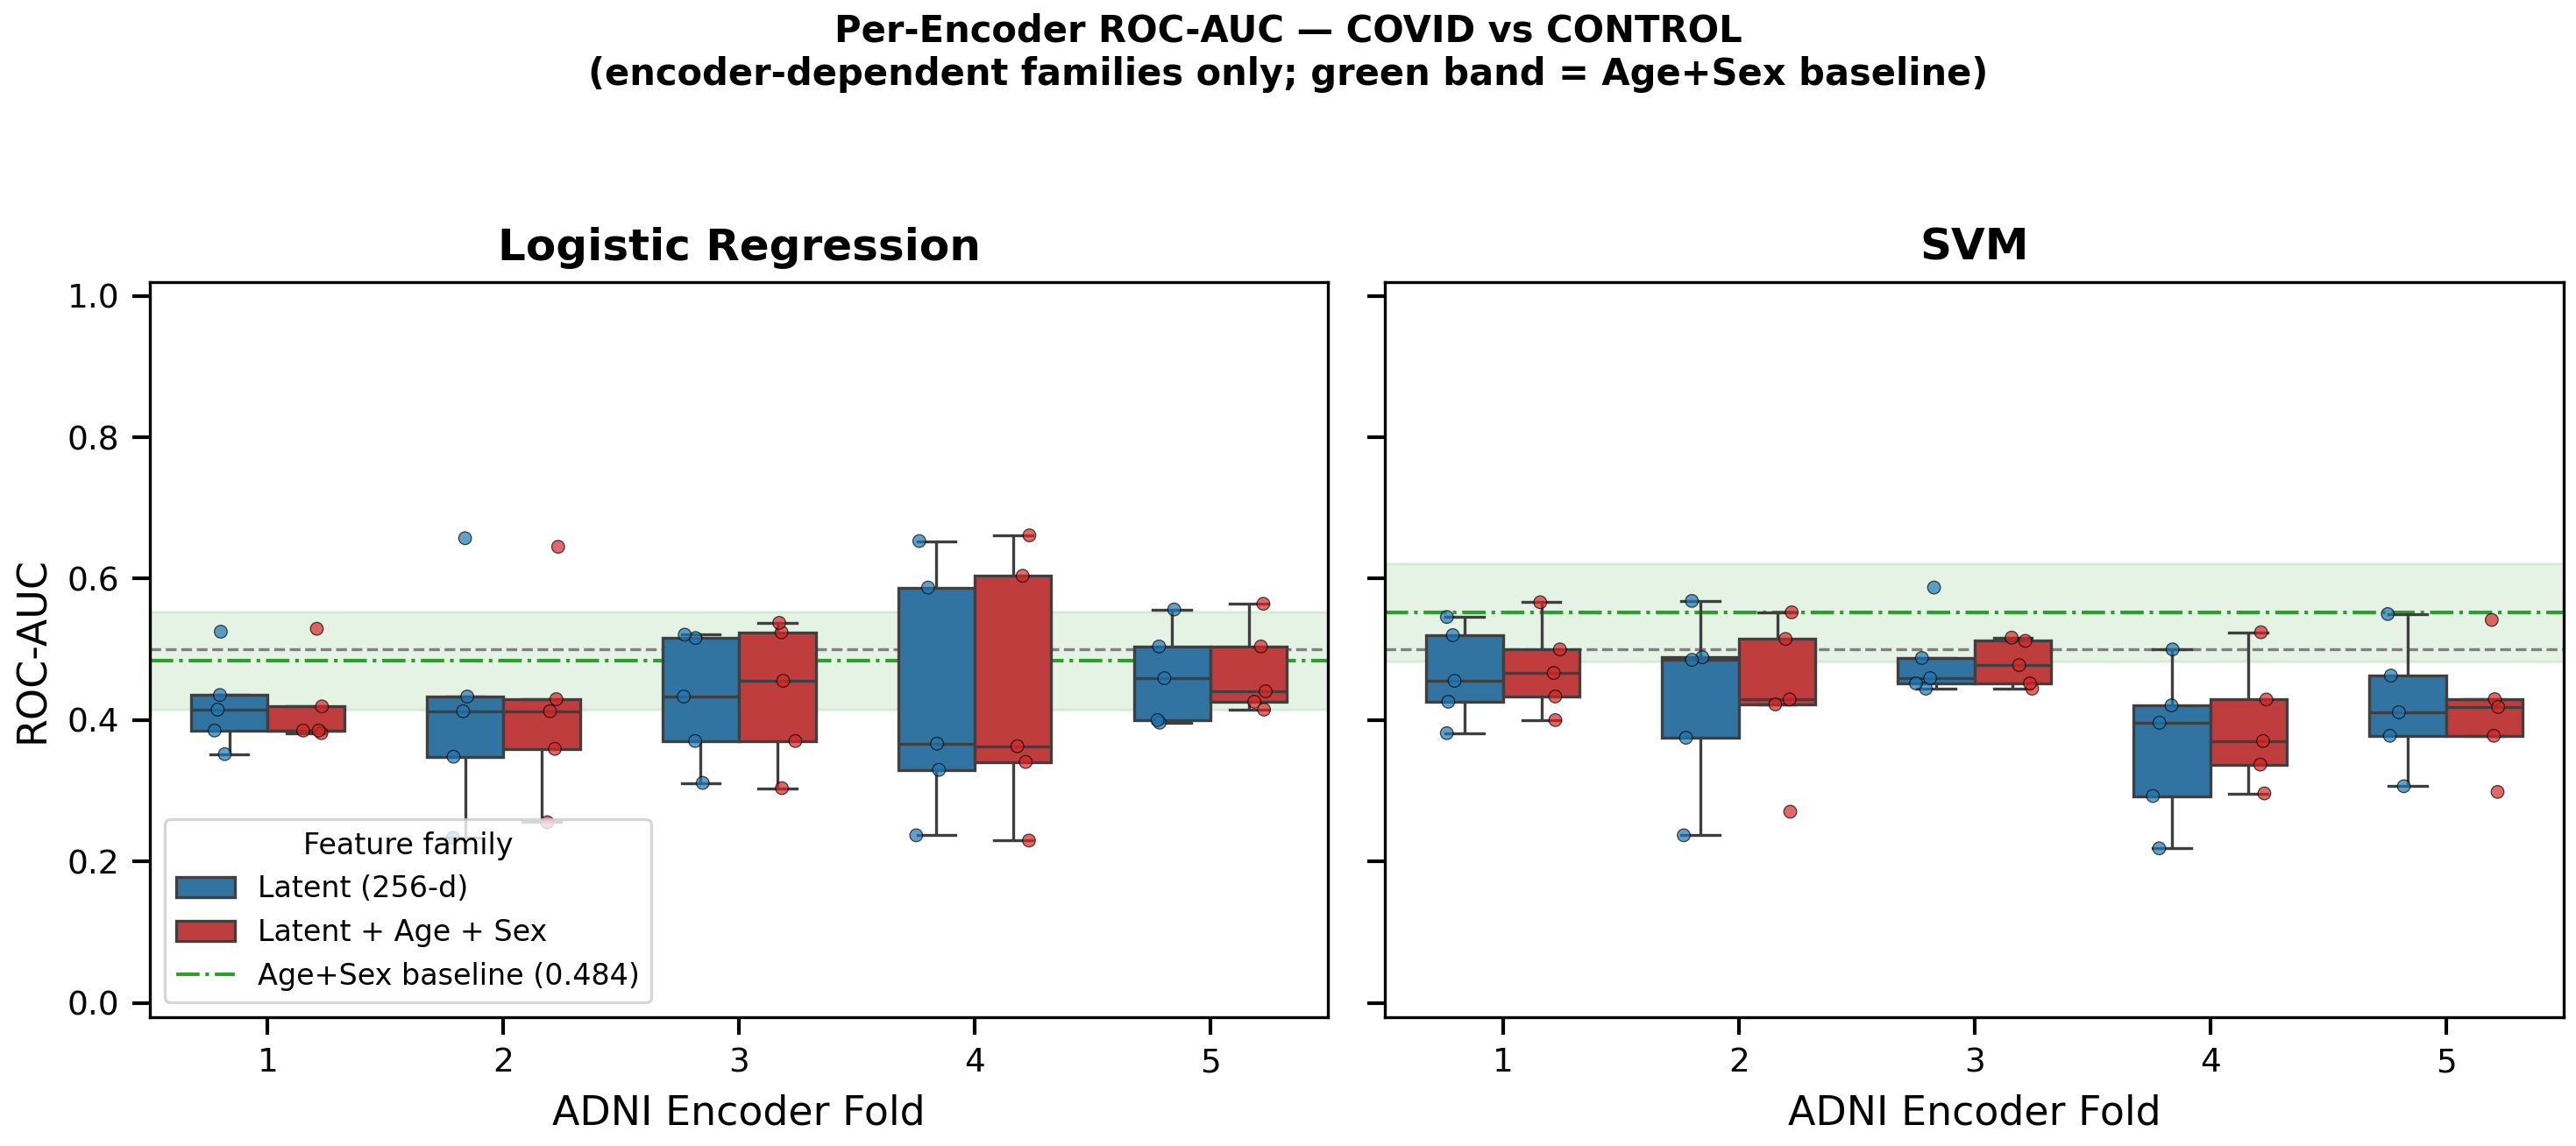

In [17]:
# ── Per-encoder AUC: only latent-dependent families ──────────────
# metadata_only is encoder-independent (adni_encoder_fold=0, trained once),
# so it is excluded from this figure and shown later as a horizontal baseline.
latent_metrics = metrics_fold[metrics_fold.feature_family != "metadata_only"].copy()

LATENT_FAMILIES = ["latent_only", "latent_plus_metadata"]
LATENT_LABEL_PALETTE = {FAMILY_LABELS[k]: FAMILY_PALETTE[k] for k in LATENT_FAMILIES}

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)

for ax, clf in zip(axes, ["logreg", "svm"]):
    sub = latent_metrics[latent_metrics.model_type == clf]
    sns.boxplot(
        data=sub, x="adni_encoder_fold", y="auc",
        hue="family_label",
        hue_order=[FAMILY_LABELS[f] for f in LATENT_FAMILIES],
        palette=LATENT_LABEL_PALETTE,
        width=0.65, linewidth=0.8, fliersize=0,
        ax=ax,
    )
    sns.stripplot(
        data=sub, x="adni_encoder_fold", y="auc",
        hue="family_label",
        hue_order=[FAMILY_LABELS[f] for f in LATENT_FAMILIES],
        palette=LATENT_LABEL_PALETTE,
        dodge=True, size=3.5, alpha=0.7, linewidth=0.3,
        edgecolor="k", ax=ax, legend=False,
    )
    # metadata_only baseline as horizontal band
    meta_auc = summary_fus.query(
        f"model_type == '{clf}' and feature_family == 'metadata_only'"
    )
    if not meta_auc.empty:
        m = meta_auc.iloc[0]
        ax.axhspan(m.auc_mean - m.auc_std, m.auc_mean + m.auc_std,
                    color=FAMILY_PALETTE["metadata_only"], alpha=0.12, zorder=0)
        ax.axhline(m.auc_mean, ls="-.", lw=1.0,
                    color=FAMILY_PALETTE["metadata_only"], zorder=0,
                    label=f"Age+Sex baseline ({m.auc_mean:.3f})")

    ax.axhline(0.5, ls="--", lw=0.8, color="gray", zorder=0)
    ax.set_title(CLF_LABELS[clf], fontweight="bold")
    ax.set_xlabel("ADNI Encoder Fold")
    ax.set_ylim(-0.02, 1.02)
    if ax == axes[0]:
        ax.set_ylabel("ROC-AUC")
        ax.legend(title="Feature family", loc="lower left", fontsize=8, title_fontsize=8)
    else:
        ax.get_legend().remove()

fig.suptitle("Per-Encoder ROC-AUC — COVID vs CONTROL\n(encoder-dependent families only; green band = Age+Sex baseline)",
             fontweight="bold", y=1.05, fontsize=10)
fig.tight_layout()
save_figure(fig, FIG_DIR / "fig_auc_by_encoder_fold", formats=FIG_FORMATS)
show_fig(fig)

## §4 — Late-Fusion Performance (Central Figure)

In [18]:
# Compute per-fold AUC from the fused OOF predictions
from sklearn.metrics import roc_auc_score

records = []
for (clf, fam, fold), g in oof_fusion.groupby(
    ["model_type", "feature_family", "covid_outer_fold"]
):
    if g.y_true.nunique() < 2:
        continue
    auc = roc_auc_score(g.y_true, g.y_score_fused)
    records.append(dict(
        model_type=clf, feature_family=fam,
        covid_outer_fold=fold, auc=auc,
    ))

fusion_foldwise = pd.DataFrame(records)
fusion_foldwise["family_label"] = fusion_foldwise.feature_family.map(FAMILY_LABELS)
fusion_foldwise["clf_label"]    = fusion_foldwise.model_type.map(CLF_LABELS)

print(f"Late-fusion fold-wise AUC: {fusion_foldwise.shape[0]} rows")
display(fusion_foldwise.head(6))

Late-fusion fold-wise AUC: 30 rows


,model_type,feature_family,covid_outer_fold,auc,family_label,clf_label
0,logreg,latent_only,0,0.285185,Latent (256-d),Logistic Regression
1,logreg,latent_only,1,0.307407,Latent (256-d),Logistic Regression
2,logreg,latent_only,2,0.400000,Latent (256-d),Logistic Regression
3,logreg,latent_only,3,0.548387,Latent (256-d),Logistic Regression
4,logreg,latent_only,4,0.608333,Latent (256-d),Logistic Regression
5,logreg,latent_plus_metadata,0,0.288889,Latent + Age + Sex,Logistic Regression


Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/covid_classification_probing/Figures/audit/fig_late_fusion_auc.png
Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/covid_classification_probing/Figures/audit/fig_late_fusion_auc.pdf


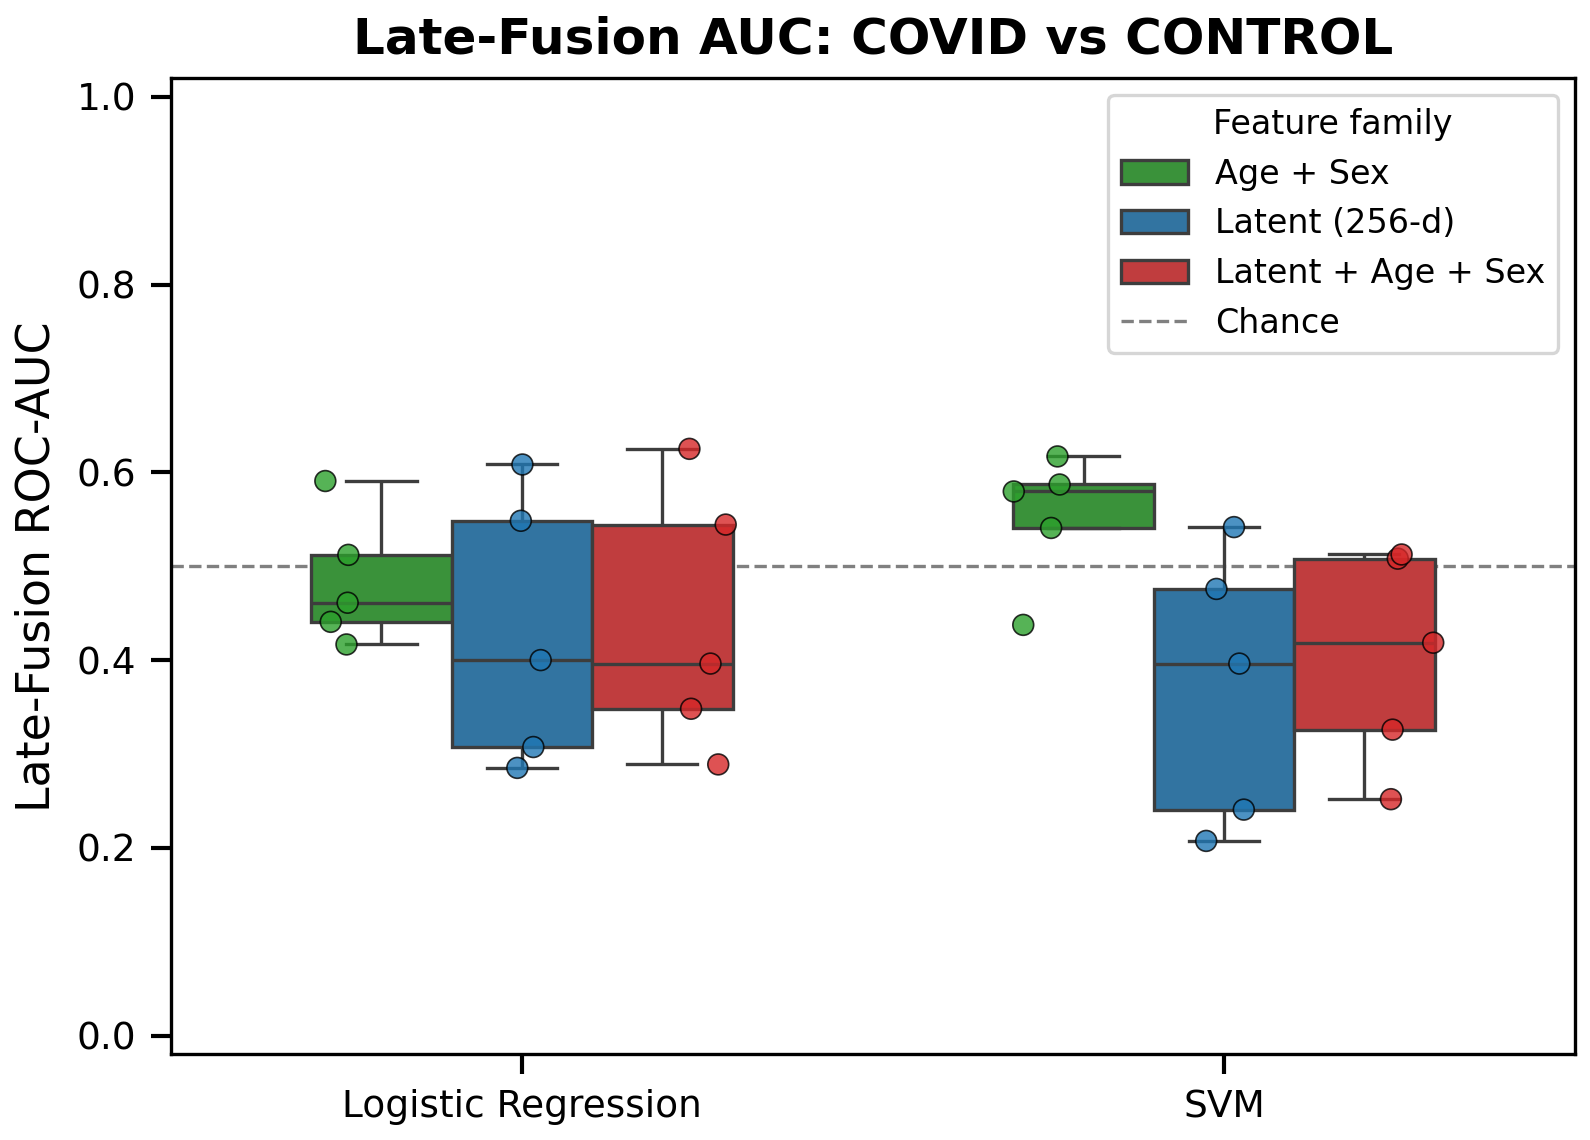

In [19]:
fig, ax = plt.subplots(figsize=(5.5, 4))

sns.boxplot(
    data=fusion_foldwise, x="clf_label", y="auc",
    hue="family_label",
    hue_order=[FAMILY_LABELS[f] for f in FAMILY_ORDER],
    palette=LABEL_PALETTE,
    width=0.6, linewidth=0.8, fliersize=0, ax=ax,
)
sns.stripplot(
    data=fusion_foldwise, x="clf_label", y="auc",
    hue="family_label",
    hue_order=[FAMILY_LABELS[f] for f in FAMILY_ORDER],
    palette=LABEL_PALETTE,
    dodge=True, size=5, alpha=0.8, linewidth=0.4,
    edgecolor="k", ax=ax, legend=False,
)

ax.axhline(0.5, ls="--", lw=0.8, color="gray", zorder=0, label="Chance")
ax.set_xlabel("")
ax.set_ylabel("Late-Fusion ROC-AUC")
ax.set_title("Late-Fusion AUC: COVID vs CONTROL", fontweight="bold")
ax.set_ylim(-0.02, 1.02)
ax.legend(title="Feature family", loc="upper right", fontsize=8, title_fontsize=8)

fig.tight_layout()
save_figure(fig, FIG_DIR / "fig_late_fusion_auc", formats=FIG_FORMATS)
show_fig(fig)

## §5 — Additional Metrics

In [20]:
# ── Summary table (late fusion) — nicely formatted ────────────────
disp = summary_fus.copy()
disp["Classifier"] = disp.model_type.map(CLF_LABELS)
disp["Features"]   = disp.feature_family.map(FAMILY_LABELS)

# Compose mean ± std strings
for metric in ["auc", "pr_auc", "balanced_accuracy", "f1", "sensitivity", "specificity"]:
    mean_col = f"{metric}_mean"
    std_col  = f"{metric}_std"
    nice = metric.upper().replace("_", " ")
    if std_col in disp.columns:
        disp[nice] = disp.apply(
            lambda r: f"{r[mean_col]:.3f} ± {r[std_col]:.3f}", axis=1
        )
    else:
        disp[nice] = disp[mean_col].map(lambda v: f"{v:.3f}")

cols_show = ["Classifier", "Features", "AUC", "PR AUC",
             "BALANCED ACCURACY", "F1", "SENSITIVITY", "SPECIFICITY"]
disp_table = disp[cols_show].sort_values(["Classifier", "Features"])
display(disp_table.style.set_caption(
    "Late-Fusion Metrics (mean ± std across 5 COVID CV folds)"
).hide(axis='index'))

# PR-AUC baseline reminder
print(f"\n⚠  PR-AUC random baseline (= positive-class prevalence) = {n_covid/n_total:.3f}")
print("   Values at or below this level are uninformative.")

Classifier,Features,AUC,PR AUC,BALANCED ACCURACY,F1,SENSITIVITY,SPECIFICITY
Logistic Regression,Age + Sex,0.484 ± 0.069,0.759 ± 0.045,0.573 ± 0.065,0.724 ± 0.080,0.655 ± 0.106,0.492 ± 0.078
Logistic Regression,Latent (256-d),0.430 ± 0.144,0.761 ± 0.074,0.449 ± 0.095,0.590 ± 0.092,0.496 ± 0.106,0.403 ± 0.194
Logistic Regression,Latent + Age + Sex,0.441 ± 0.140,0.767 ± 0.071,0.459 ± 0.096,0.605 ± 0.112,0.516 ± 0.128,0.403 ± 0.194
SVM,Age + Sex,0.552 ± 0.070,0.819 ± 0.049,0.558 ± 0.066,0.716 ± 0.078,0.649 ± 0.118,0.467 ± 0.160
SVM,Latent (256-d),0.372 ± 0.145,0.735 ± 0.080,0.491 ± 0.020,0.816 ± 0.137,0.893 ± 0.239,0.089 ± 0.199
SVM,Latent + Age + Sex,0.403 ± 0.114,0.749 ± 0.077,0.504 ± 0.010,0.871 ± 0.015,0.987 ± 0.030,0.022 ± 0.050



⚠  PR-AUC random baseline (= positive-class prevalence) = 0.778
   Values at or below this level are uninformative.


Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/covid_classification_probing/Figures/audit/fig_additional_metrics.png
Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/covid_classification_probing/Figures/audit/fig_additional_metrics.pdf


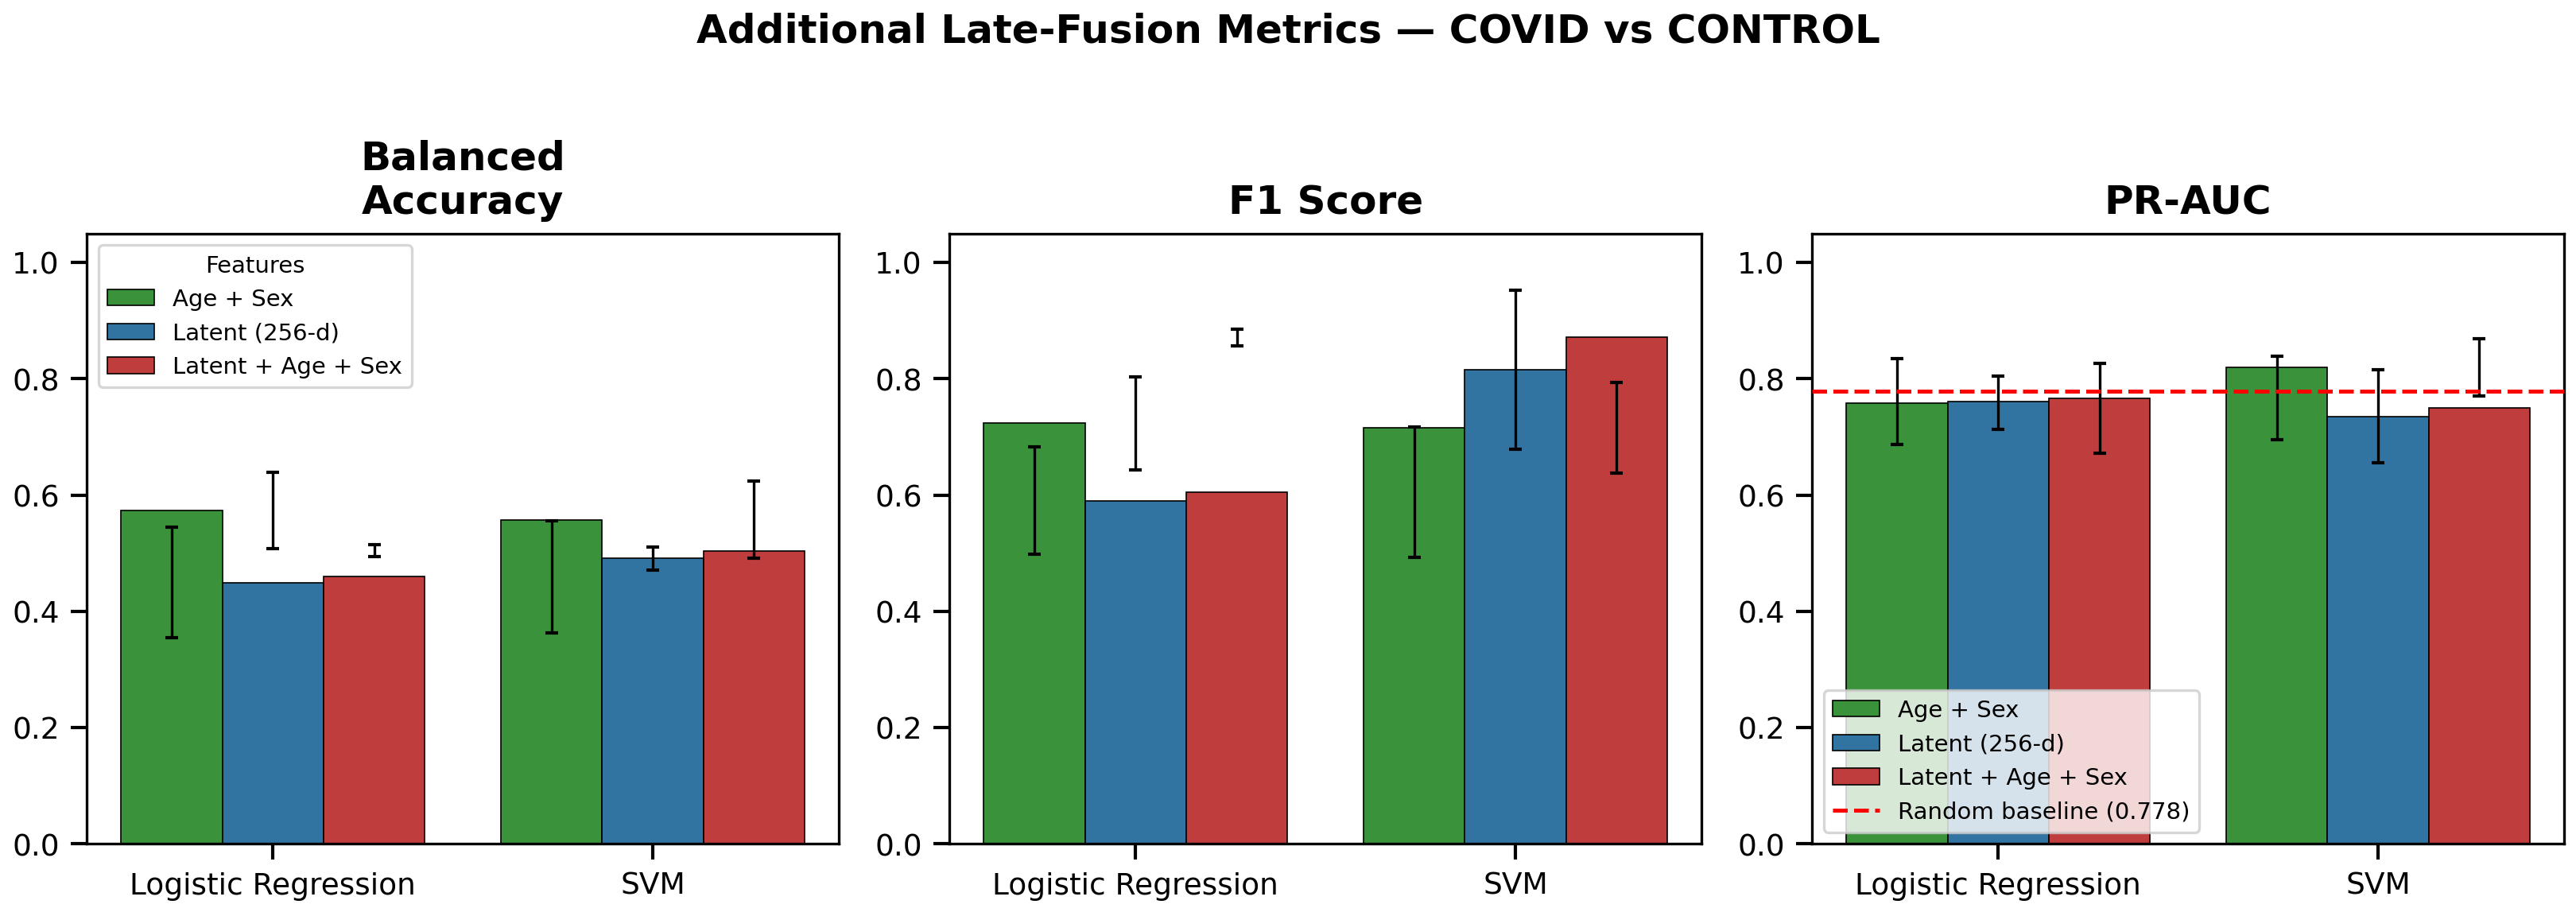

In [21]:
# ── Compact barplot of additional metrics ─────────────────────────
extra_metrics = ["balanced_accuracy", "f1", "pr_auc"]
METRIC_LABELS = {
    "balanced_accuracy": "Balanced\nAccuracy",
    "f1": "F1 Score",
    "pr_auc": "PR-AUC",
}

# PR-AUC baseline for a random classifier equals the positive-class
# prevalence: P(COVID) ≈ 0.778.  Values at or below this are uninformative.
PR_AUC_BASELINE = n_covid / n_total  # ≈ 0.778

fig, axes = plt.subplots(1, len(extra_metrics), figsize=(11, 3.8), sharey=False)

for ax, metric in zip(axes, extra_metrics):
    mean_col = f"{metric}_mean"
    std_col  = f"{metric}_std"
    plot_df = summary_fus.copy()
    plot_df["family_label"] = plot_df.feature_family.map(FAMILY_LABELS)
    plot_df["clf_label"]    = plot_df.model_type.map(CLF_LABELS)

    sns.barplot(
        data=plot_df, x="clf_label", y=mean_col,
        hue="family_label",
        hue_order=[FAMILY_LABELS[f] for f in FAMILY_ORDER],
        palette=LABEL_PALETTE,
        ax=ax, edgecolor="k", linewidth=0.4,
    )
    # error bars
    if std_col in plot_df.columns:
        x_coords = []
        for container in ax.containers:
            for bar in container:
                x_coords.append(bar.get_x() + bar.get_width() / 2)
        y_vals = plot_df.sort_values(["model_type", "feature_family"])[mean_col].values
        y_errs = plot_df.sort_values(["model_type", "feature_family"])[std_col].values
        if len(x_coords) == len(y_vals):
            ax.errorbar(x_coords, y_vals, yerr=y_errs, fmt="none",
                        ecolor="k", elinewidth=0.8, capsize=2)

    # PR-AUC: add random-classifier baseline
    if metric == "pr_auc":
        ax.axhline(PR_AUC_BASELINE, ls="--", lw=1.2, color="red", zorder=5,
                    label=f"Random baseline ({PR_AUC_BASELINE:.3f})")
        ax.legend(fontsize=7, loc="lower left")

    ax.set_title(METRIC_LABELS[metric], fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_ylim(0, 1.05)
    if metric != "pr_auc" and ax != axes[0]:
        ax.get_legend().remove()
    elif metric != "pr_auc" and ax == axes[0]:
        ax.legend(title="Features", fontsize=7, title_fontsize=7, loc="upper left")

fig.suptitle("Additional Late-Fusion Metrics — COVID vs CONTROL", fontweight="bold", y=1.02)
fig.tight_layout()
save_figure(fig, FIG_DIR / "fig_additional_metrics", formats=FIG_FORMATS)
show_fig(fig)

## §6 — Prediction Score Distributions

Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/covid_classification_probing/Figures/audit/fig_score_distributions.png
Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/covid_classification_probing/Figures/audit/fig_score_distributions.pdf


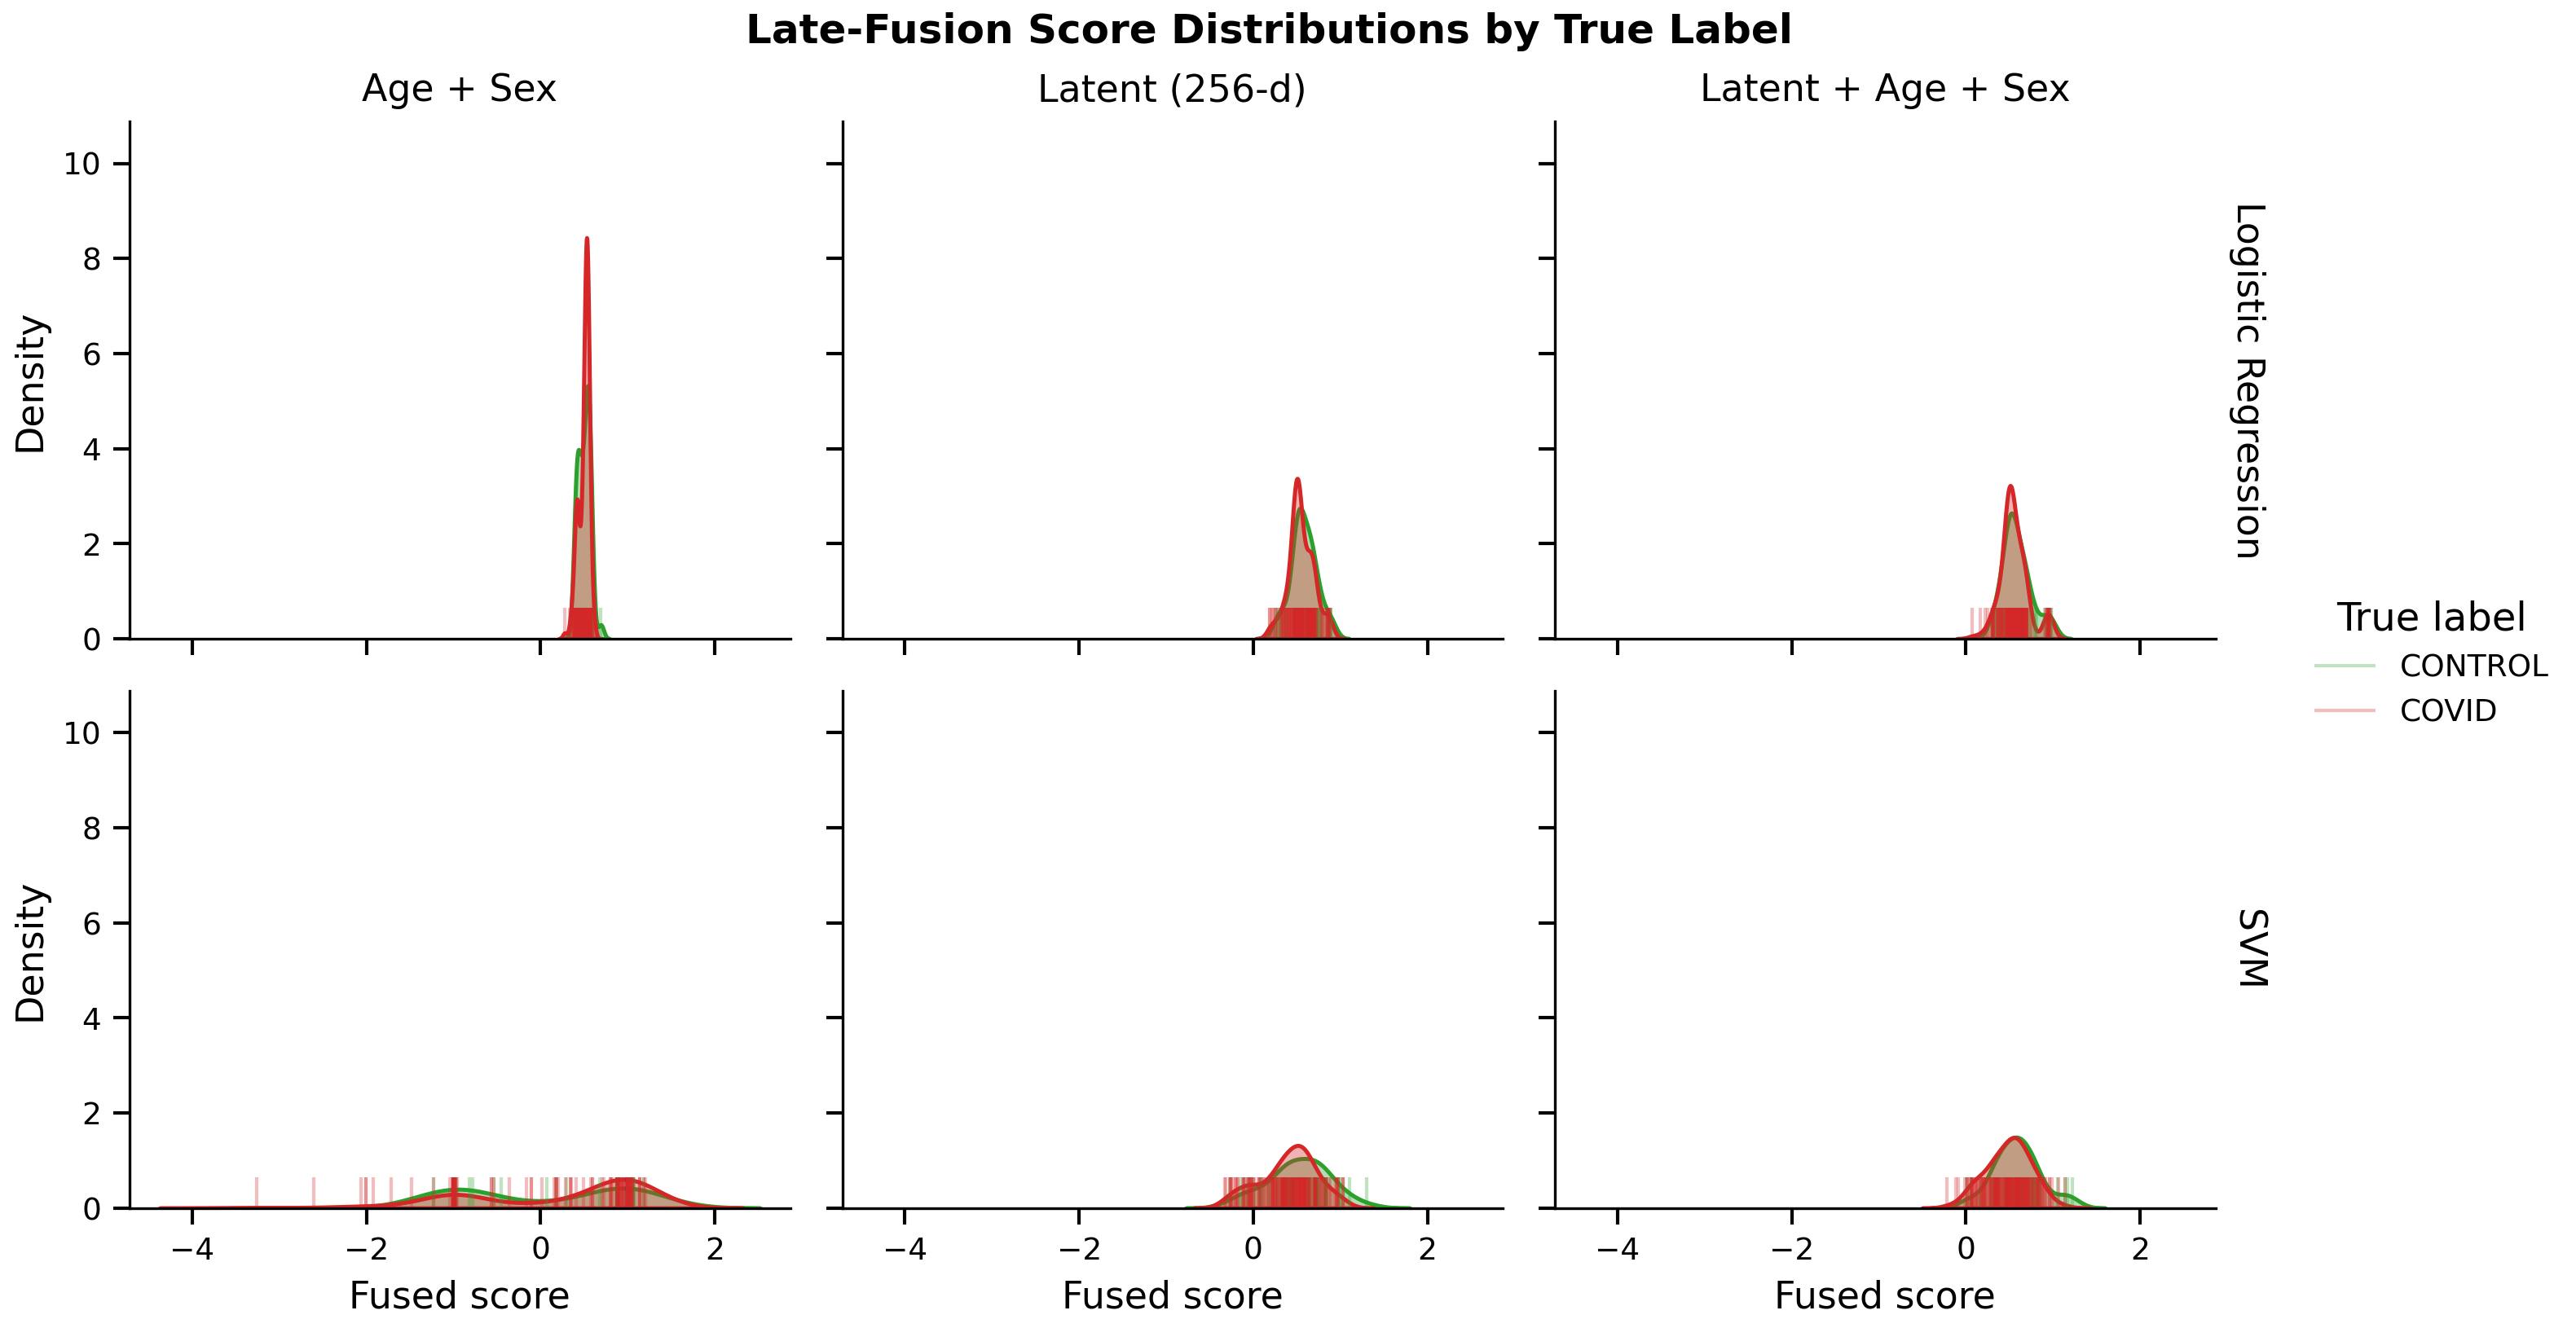

In [22]:
oof_fusion["family_label"] = oof_fusion.feature_family.map(FAMILY_LABELS)
oof_fusion["clf_label"]    = oof_fusion.model_type.map(CLF_LABELS)
oof_fusion["true_label"]   = oof_fusion.y_true.map({0: "CONTROL", 1: "COVID"})

TRUE_PALETTE = {"CONTROL": "#2ca02c", "COVID": "#d62728"}

g = sns.FacetGrid(
    oof_fusion, col="family_label", row="clf_label",
    col_order=[FAMILY_LABELS[f] for f in FAMILY_ORDER],
    hue="true_label", hue_order=["CONTROL", "COVID"],
    palette=TRUE_PALETTE,
    height=2.8, aspect=1.15, margin_titles=True,
)
g.map(sns.kdeplot, "y_score_fused", fill=True, alpha=0.35, linewidth=1.2, common_norm=False)
g.map(sns.rugplot, "y_score_fused", height=0.06, alpha=0.3)
g.add_legend(title="True label")
g.set_axis_labels("Fused score", "Density")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.figure.subplots_adjust(top=0.90)
g.figure.suptitle("Late-Fusion Score Distributions by True Label", fontweight="bold")

save_figure(g.figure, FIG_DIR / "fig_score_distributions", formats=FIG_FORMATS)
show_fig(g.figure)

## §7 — Heatmap: Mean AUC by Classifier × Feature Family

Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/covid_classification_probing/Figures/audit/fig_auc_heatmap.png
Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/covid_classification_probing/Figures/audit/fig_auc_heatmap.pdf


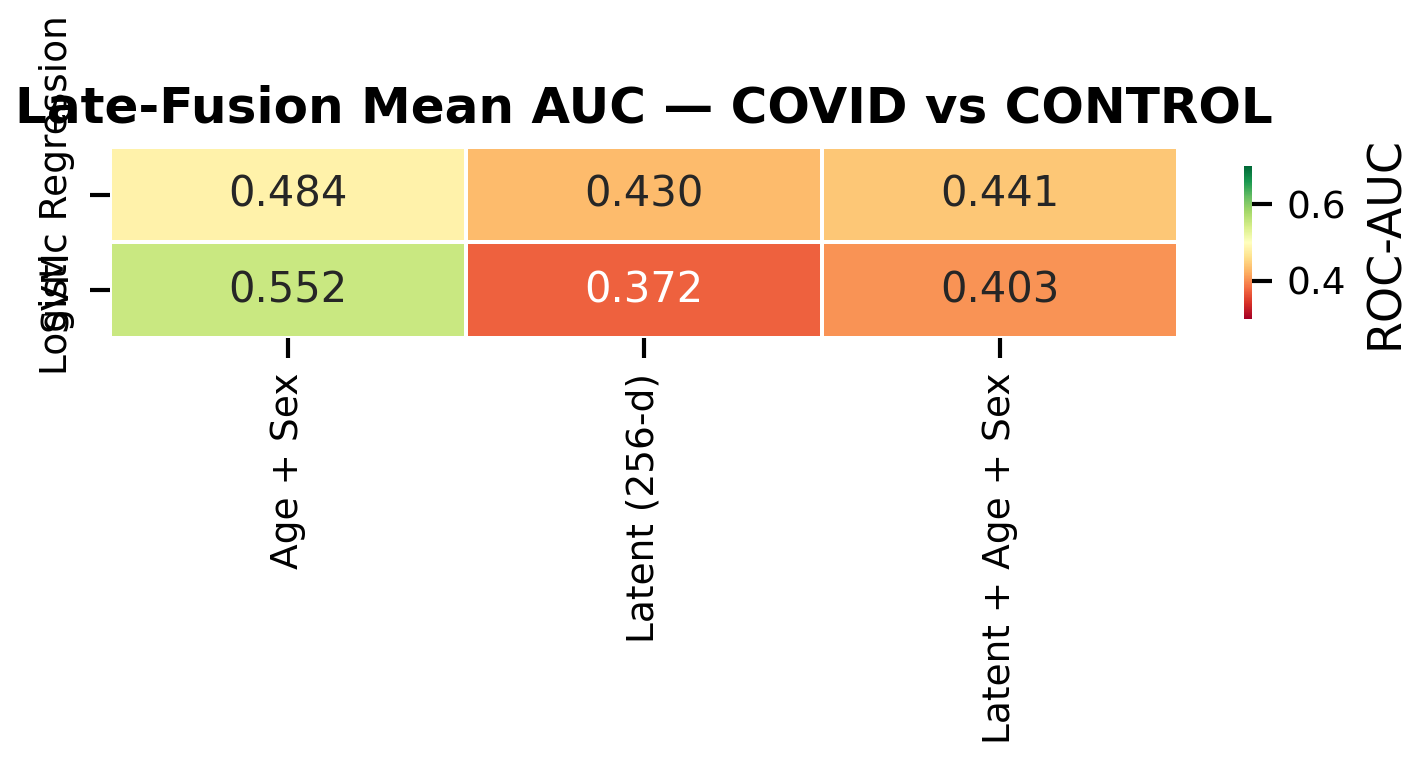

In [23]:
# ── Heatmap of late-fusion AUC ───────────────────────────────────
heat = summary_fus.pivot(
    index="model_type", columns="feature_family", values="auc_mean"
).rename(index=CLF_LABELS, columns=FAMILY_LABELS)
heat = heat[[FAMILY_LABELS[f] for f in FAMILY_ORDER]]

fig, ax = plt.subplots(figsize=(5, 2.5))
sns.heatmap(
    heat, annot=True, fmt=".3f", cmap="RdYlGn",
    vmin=0.3, vmax=0.7, linewidths=0.5,
    cbar_kws={"label": "ROC-AUC", "shrink": 0.8},
    ax=ax,
)
ax.set_title("Late-Fusion Mean AUC — COVID vs CONTROL", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")

fig.tight_layout()
save_figure(fig, FIG_DIR / "fig_auc_heatmap", formats=FIG_FORMATS)
show_fig(fig)

Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/covid_classification_probing/Figures/audit/fig_encoder_variance.png
Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/covid_classification_probing/Figures/audit/fig_encoder_variance.pdf


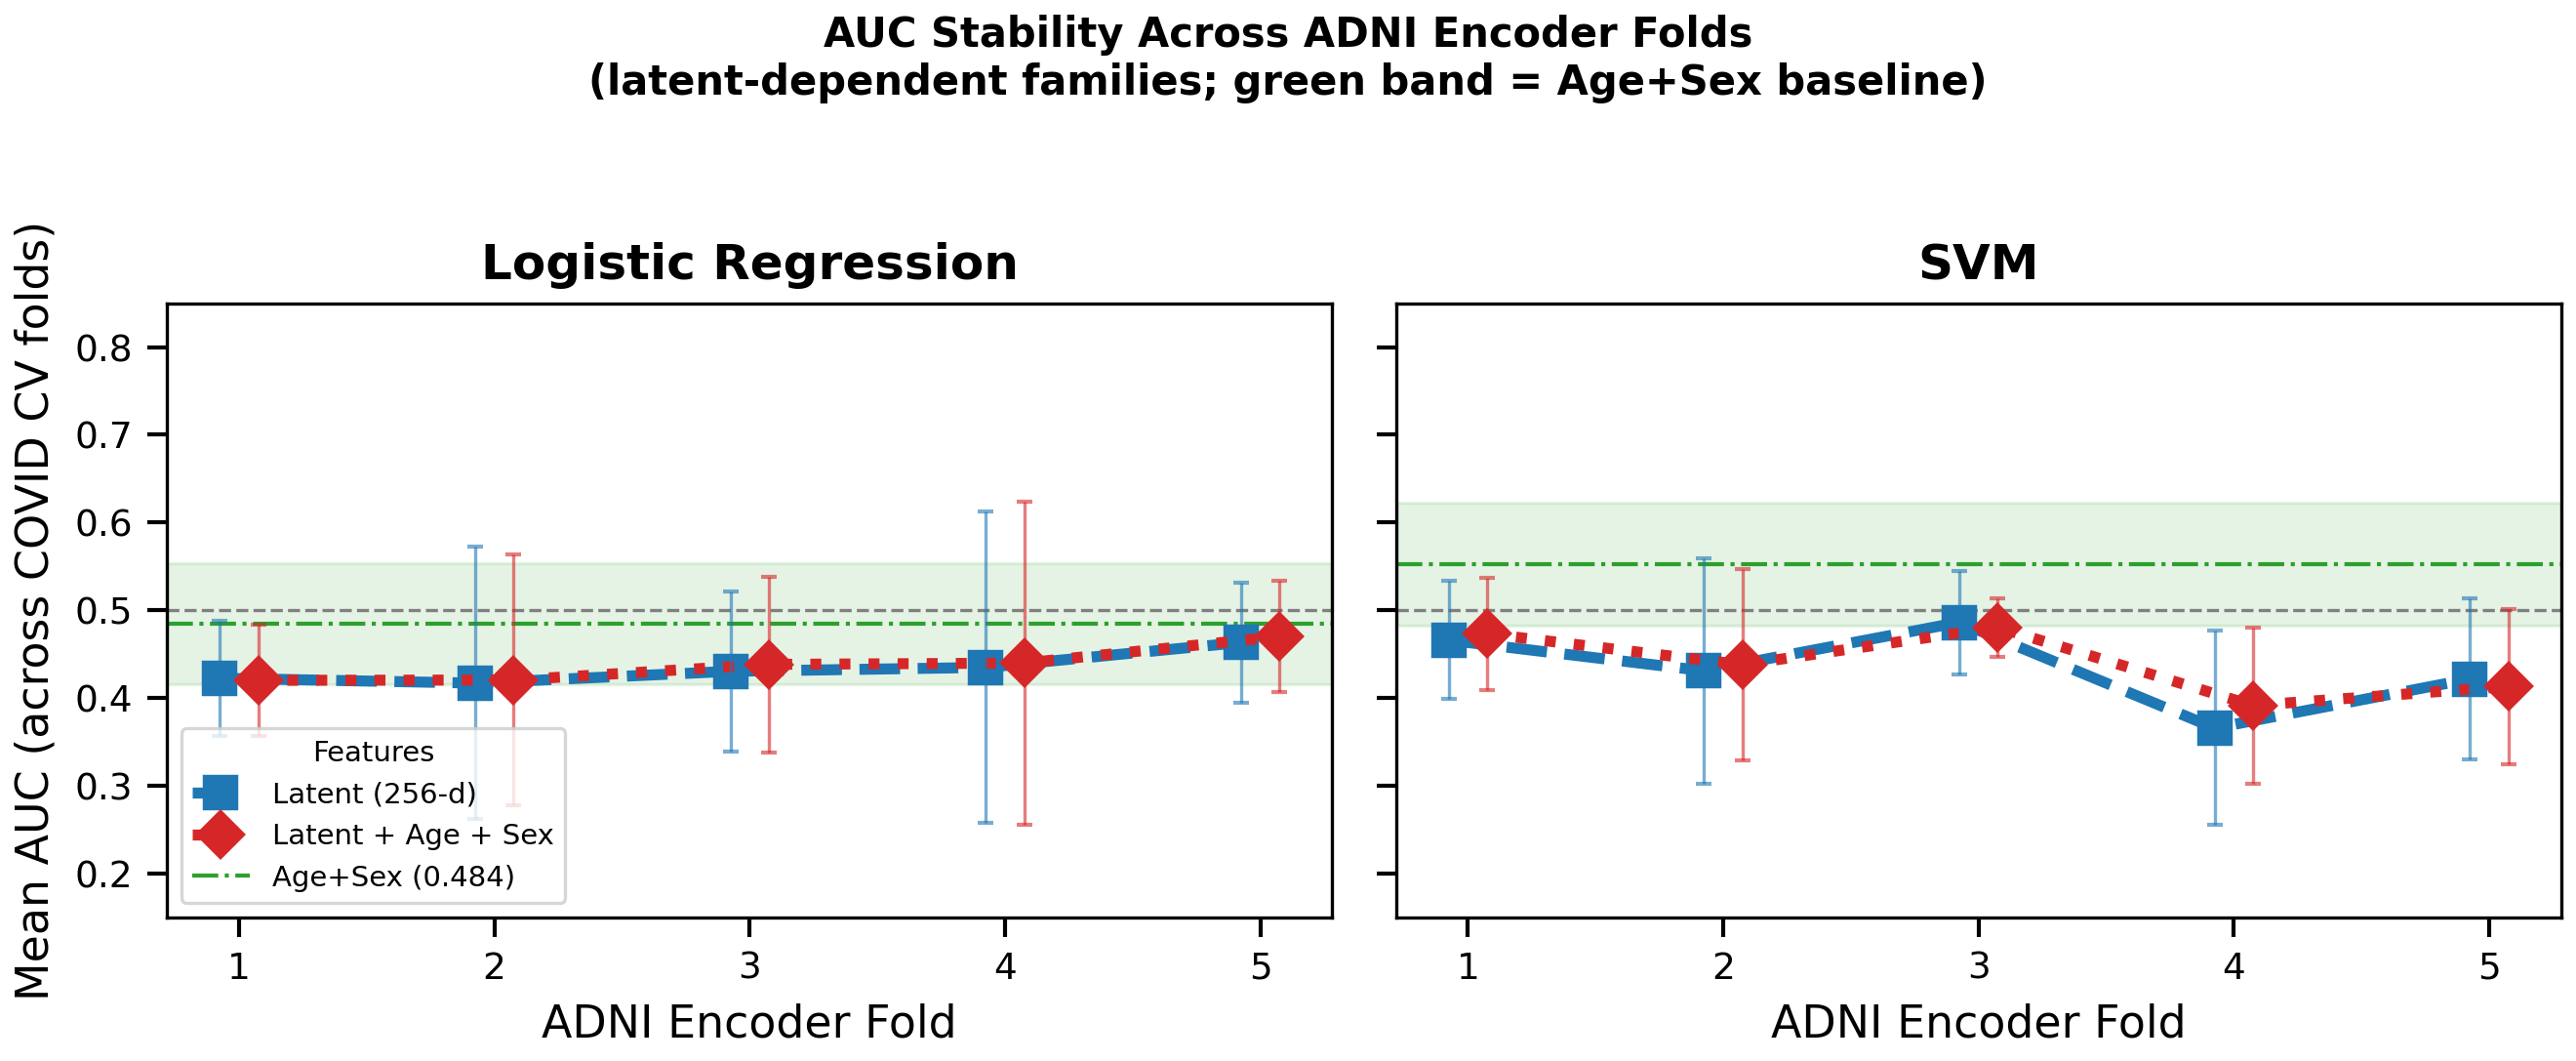

In [24]:
# ── Variance across encoder folds (latent-dependent families only) ─
# metadata_only has a single entry (adni_encoder_fold=0) — it is not
# encoder-dependent and is omitted from this figure.
var_df = summary_enc[summary_enc.feature_family != "metadata_only"].copy()
var_df["family_label"] = var_df.feature_family.map(FAMILY_LABELS)
var_df["clf_label"]    = var_df.model_type.map(CLF_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True)

for ax, clf in zip(axes, ["logreg", "svm"]):
    sub = var_df[var_df.model_type == clf]
    sns.pointplot(
        data=sub, x="adni_encoder_fold", y="auc_mean",
        hue="family_label",
        hue_order=[FAMILY_LABELS[f] for f in LATENT_FAMILIES],
        palette={FAMILY_LABELS[k]: FAMILY_PALETTE[k] for k in LATENT_FAMILIES},
        markers=["s", "D"], linestyles=["--", ":"],
        dodge=0.15, errorbar=None, ax=ax,
    )
    # error bars from auc_std
    for fam_i, fam in enumerate(LATENT_FAMILIES):
        sub_f = sub[sub.feature_family == fam].sort_values("adni_encoder_fold")
        x_positions = np.arange(len(sub_f)) + (fam_i - 0.5) * 0.15
        ax.errorbar(
            x_positions, sub_f.auc_mean.values, yerr=sub_f.auc_std.values,
            fmt="none", ecolor=FAMILY_PALETTE[fam], elinewidth=0.8, capsize=2, alpha=0.6,
        )

    # metadata_only baseline band
    meta_auc = summary_fus.query(
        f"model_type == '{clf}' and feature_family == 'metadata_only'"
    )
    if not meta_auc.empty:
        m = meta_auc.iloc[0]
        ax.axhspan(m.auc_mean - m.auc_std, m.auc_mean + m.auc_std,
                    color=FAMILY_PALETTE["metadata_only"], alpha=0.12, zorder=0)
        ax.axhline(m.auc_mean, ls="-.", lw=1.0,
                    color=FAMILY_PALETTE["metadata_only"], zorder=0,
                    label=f"Age+Sex ({m.auc_mean:.3f})")

    ax.axhline(0.5, ls="--", lw=0.8, color="gray", zorder=0)
    ax.set_title(CLF_LABELS[clf], fontweight="bold")
    ax.set_xlabel("ADNI Encoder Fold")
    ax.set_ylim(0.15, 0.85)
    if ax == axes[0]:
        ax.set_ylabel("Mean AUC (across COVID CV folds)")
        ax.legend(title="Features", fontsize=7, title_fontsize=7, loc="lower left")
    else:
        ax.get_legend().remove()

fig.suptitle("AUC Stability Across ADNI Encoder Folds\n(latent-dependent families; green band = Age+Sex baseline)",
             fontweight="bold", y=1.05, fontsize=10)
fig.tight_layout()
save_figure(fig, FIG_DIR / "fig_encoder_variance", formats=FIG_FORMATS)
show_fig(fig)

## §8 — Scientific Interpretation

### Score types and late fusion

Logistic regression produces `predict_proba[:,1]` (a calibrated probability in [0, 1]), while SVM with `probability=False` produces `decision_function` (an unbounded signed margin). Within each classifier type, scores are commensurable across encoder folds, so averaging them during late fusion is valid. AUC is rank-based and therefore insensitive to the score scale.

### Do latent connectomic features provide signal beyond Age and Sex?

**No.** The `metadata_only` baseline — using only Age and Sex, trained once per (CV fold × classifier) with **no encoder dependency** — is on par with or above the latent-based families. Adding the 256-dimensional latent representations does not improve discrimination; both `latent_only` and `latent_plus_metadata` achieve AUC values that hover near 0.5 (chance level).

This is consistent with the unfavorable feature-to-sample ratio: 256 latent dimensions for only 194 subjects (~1.3:1 ratio) creates conditions where classifiers are likely to overfit to noise rather than extracting genuine discriminative patterns.

### PR-AUC caveat

The positive class (COVID) has **77.8 % prevalence** in this cohort. A random classifier therefore achieves PR-AUC ≈ 0.778 by default. Any observed PR-AUC at or below this level is **uninformative** — it does not indicate predictive power. The values reported in §5 must be interpreted relative to this baseline, not in absolute terms.

### Is performance stable across encoders?

For the latent-dependent families, inter-fold AUC variance is substantial (std ≈ 0.10–0.15 across the five ADNI encoder folds), confirming that the specific encoder used influences downstream classification — but not in a way that improves discriminative power.

### Does late fusion improve robustness?

Late fusion (averaging predicted scores across the five independently trained encoders) provides a principled way to reduce encoder-specific variance without the invalid operation of averaging latent vectors. However, because none of the individual encoders capture COVID-relevant signal, fusing them does not rescue performance. The fusion concentrates score distributions slightly but does not shift them in a class-discriminative direction.

### Conclusion

The β-VAE encoders trained on ADNI (AD vs CN) learn latent representations of brain connectivity that are **not transferable to the COVID vs CONTROL discrimination task**. This is biologically plausible: Alzheimer's neurodegeneration and post-COVID neurological effects likely involve distinct network-level signatures that a model trained only on one cannot generalize to the other. Within this cohort, Age and Sex alone represent the performance ceiling for the available feature set.

**Important caveat:** All results pertain to COVID vs CONTROL classification within this specific cohort (n=194, class ratio ≈ 3.5:1). The negative finding regarding latent feature transfer does not preclude the use of other encoder architectures, training objectives, or larger COVID-specific cohorts.

### Polarity verification

Score polarity was verified: `classes_ = [0, 1]` where 1 = COVID. Higher scores from logistic regression correspond to higher P(COVID); higher SVM decision function corresponds to the COVID class. Sub-0.5 AUC values in the latent families reflect **genuine inability** to discriminate, not a sign-flip artifact.